# Trajectory and Pseudotime Analysis

The previous notebooks dealt with discrete cell types — cells were assigned to one of a fixed set of clusters. But biology is often continuous. Cells differentiate, activate, or cycle through states in an ordered sequence.

**Pseudotime** is a computational ordering of cells along a trajectory, inferred from transcriptional similarity rather than real time. A cell with pseudotime 0.1 is transcriptionally earlier in the process than one with pseudotime 0.9.

## When is trajectory analysis appropriate?

Trajectory analysis assumes your data contains a biological process with a directional order — differentiation, activation, or a developmental sequence. It is **not appropriate** for mature, terminally differentiated populations with no meaningful ordering.

PBMC data (used in Notebooks 1 and 2) is not well-suited for this: blood immune cells are mostly mature and do not form interpretable trajectories. We switch datasets here for that reason.

## What we will do

1. Load a bone marrow dataset with known myeloid differentiation
2. Identify connectivity between cell states using PAGA
3. Order cells along a trajectory using Diffusion Pseudotime
4. Visualize how gene expression changes along the trajectory

---
# 1. Setup and Data
---

We use the **Paul et al. (2015)** mouse bone marrow dataset, built into Scanpy. It contains ~2700 cells from multiple myeloid lineages, including erythrocyte precursors, granulocytes, and monocytes — all derived from common progenitors.

This dataset is widely used for trajectory analysis benchmarks precisely because the biology is well-established: we know which cells should come first (progenitors) and which come last (mature effector cells).

In [1]:
import scanpy as sc
import numpy as np
import matplotlib.pyplot as plt

sc.settings.verbosity = 1
sc.set_figure_params(dpi=80)

adata = sc.datasets.paul15()
print(adata)
print("\nCell type labels:")
print(adata.obs['paul15_clusters'].value_counts())

AnnData object with n_obs × n_vars = 2730 × 3451
    obs: 'paul15_clusters'
    uns: 'iroot'

Cell type labels:
paul15_clusters
14Mo       373
2Ery       329
13Baso     300
3Ery       246
15Mo       186
5Ery       180
6Ery       173
7MEP       167
16Neu      164
10GMP      153
4Ery       124
12Baso      69
8Mk         68
9GMP        63
1Ery        43
19Lymph     31
11DC        30
17Neu       22
18Eos        9
Name: count, dtype: int64


## Understanding the labels

The `paul15_clusters` column contains 19 pre-annotated cell types from the original publication. The naming convention encodes both identity and a rough ordering:

- `7MEP` — Megakaryocyte-Erythrocyte Progenitor (multipotent, early in erythroid lineage)
- `0Ery`, `1Ery`, `2Ery`, `3Ery` — Erythrocyte precursors at increasing maturity
- `6Mono1`, `5Mono2` — Monocyte lineage
- `4GMP` — Granulocyte-Monocyte Progenitor
- `8Mk` — Megakaryocytes

The progenitor populations (MEP, GMP) should appear at the beginning of a trajectory; mature erythrocytes and monocytes at the end.

---
# 2. Preprocessing
---

Standard pipeline: normalize, log-transform, select highly variable genes, scale, PCA, and build a neighborhood graph. This is identical in principle to Notebook 1.

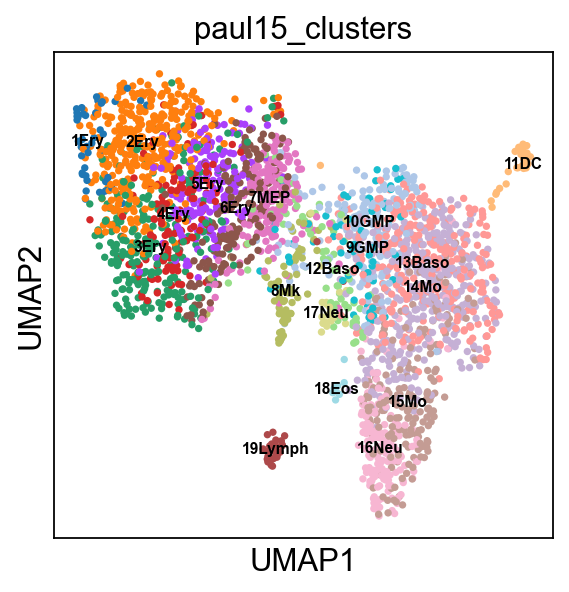

In [2]:
adata.X = adata.X.astype(float)  # ensure float dtype for downstream operations

sc.pp.normalize_total(adata, target_sum=1e4)
sc.pp.log1p(adata)
sc.pp.highly_variable_genes(adata, n_top_genes=1000)

# Pin marker genes used in section 6 so they survive the HVG subset
for g in ["Epor", "Gypa", "Hba-a2"]:
    if g in adata.var_names:
        adata.var.loc[g, "highly_variable"] = True

adata = adata[:, adata.var.highly_variable].copy()
sc.pp.scale(adata, max_value=10)
sc.tl.pca(adata, svd_solver='arpack')
sc.pp.neighbors(adata, n_neighbors=10, n_pcs=50)
sc.tl.umap(adata)

# Visualize the known cell types on UMAP
sc.pl.umap(adata, color='paul15_clusters', legend_loc='on data', legend_fontsize=7)

---
# 3. PAGA: Cluster Connectivity
---

Before computing pseudotime, we use **PAGA** (Partition-based Graph Abstraction) to understand which cell populations are connected and how.

PAGA works by testing the kNN graph for statistically significant connections between clusters. The result is a graph where:
- **Nodes** = cell clusters
- **Edge thickness** = strength of connectivity between clusters (thicker = more cells connect across that boundary)

This gives a topological overview of the data before committing to a specific trajectory direction.

## Why PAGA before pseudotime?

Pseudotime requires choosing a root — a starting point for the ordering. PAGA helps you make that choice by showing which clusters are plausibly upstream of others based on connectivity, rather than guessing.

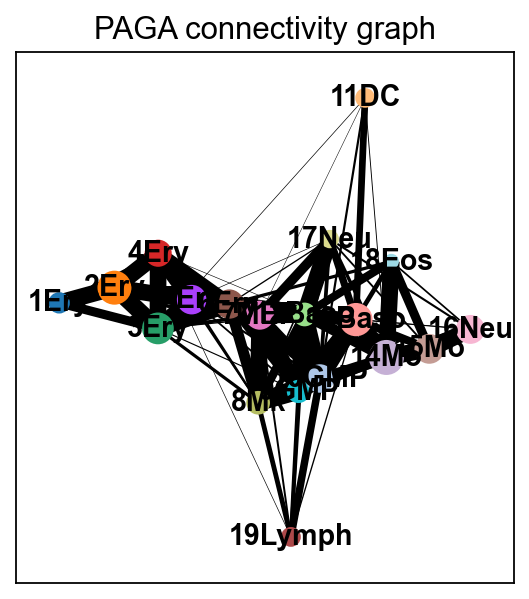

In [3]:
# Compute PAGA graph using the pre-annotated cell type labels
sc.tl.paga(adata, groups='paul15_clusters')

# Plot the PAGA graph
# Threshold filters weak connections to reduce visual clutter
sc.pl.paga(
    adata,
    color=['paul15_clusters'],
    threshold=0.03,
    title='PAGA connectivity graph'
)

## Reading the PAGA graph

- Clusters with thick edges are transcriptionally adjacent — cells from these populations mix in the neighborhood graph
- Progenitor populations (MEP, GMP) should appear centrally connected to multiple lineages
- Terminal populations (mature erythrocytes, monocytes) should appear at the periphery with fewer connections

If the graph shows an unexpected topology (e.g., a mature cell type connected to a distant progenitor), it suggests either a biological finding or a preprocessing issue worth investigating.

---
# 4. Choosing a Root Cell
---

Diffusion Pseudotime requires a root — a single cell that is defined as the biological starting point. Pseudotime 0 is assigned to the root; all other cells receive a value reflecting how far they are from it in diffusion space.

## Biological rationale

We choose a cell from the **MEP** (Megakaryocyte-Erythrocyte Progenitor) cluster as the root. MEPs are early progenitors that give rise to both erythrocytes and megakaryocytes, placing them upstream of the main trajectories visible in this dataset.

This choice should be guided by biology, not by what produces a visually satisfying plot.

In [4]:
# Find the index of the first cell in the MEP cluster
root_idx = np.flatnonzero(adata.obs['paul15_clusters'] == '7MEP')[0]
adata.uns['iroot'] = root_idx

print(f"Root cell index: {root_idx}")
print(f"Root cell cluster: {adata.obs['paul15_clusters'].iloc[root_idx]}")

Root cell index: 0
Root cell cluster: 7MEP


---
# 5. Diffusion Pseudotime
---

**Diffusion Pseudotime (DPT)** models transcriptional transitions as a diffusion process on the kNN graph. Starting from the root, it computes how many diffusion steps each cell is from the origin.

The result is a scalar value per cell (`dpt_pseudotime`) ranging from 0 (root) to 1 (most distant cell in the trajectory).

DPT first computes a **diffusion map** — a lower-dimensional representation that emphasizes continuous transitions rather than discrete clusters. Pseudotime is then computed on this diffusion map.

In [5]:
# Compute diffusion map (required for DPT)
sc.tl.diffmap(adata)

# Compute diffusion pseudotime
sc.tl.dpt(adata)

print("Pseudotime range:", adata.obs['dpt_pseudotime'].min().round(3),
      "to", adata.obs['dpt_pseudotime'].max().round(3))

Pseudotime range: 0.0 to 1.0


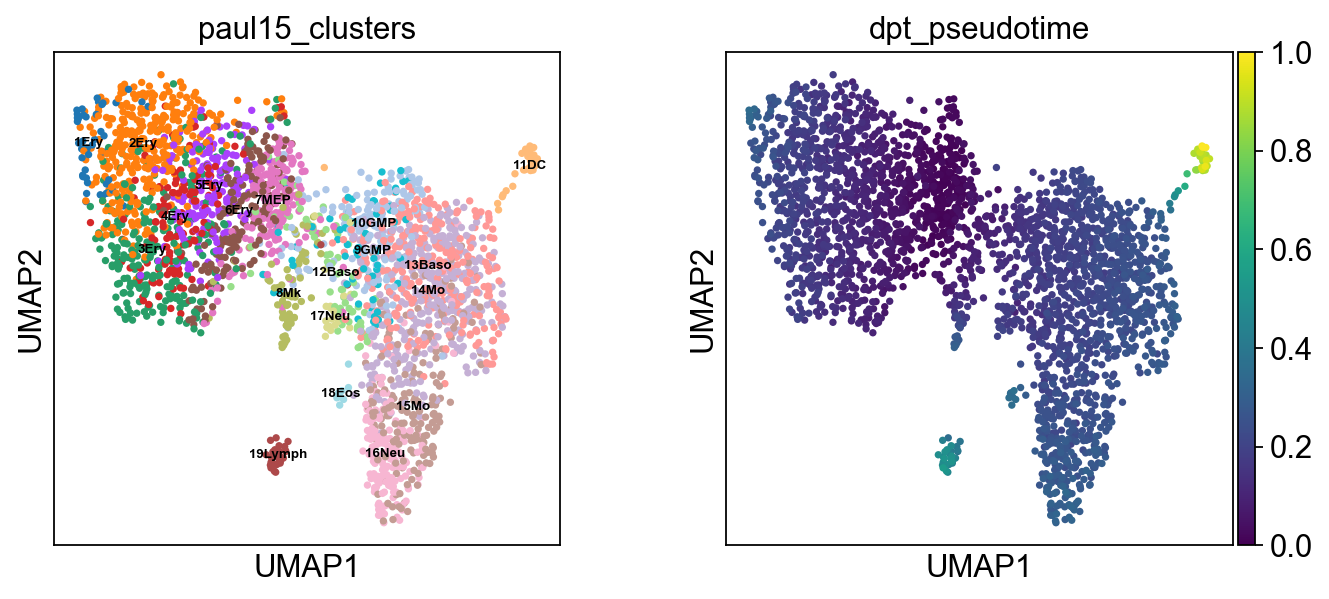

In [6]:
# Compare cell type labels with pseudotime on UMAP
sc.pl.umap(
    adata,
    color=['paul15_clusters', 'dpt_pseudotime'],
    ncols=2,
    legend_loc='on data',
    legend_fontsize=6
)

## What to look for

- The root cluster (MEP) should have pseudotime values near 0
- Terminal populations (mature erythrocytes, monocytes) should have values near 1
- Pseudotime should increase smoothly across the UMAP — abrupt jumps suggest the trajectory topology is not well-captured

If the gradient looks reversed or does not match biological expectations, try a different root cell from the same progenitor cluster, or reconsider whether the root cluster is appropriate.

---
# 6. Gene Expression Along Pseudotime
---

With cells ordered by pseudotime, we can ask: which genes are upregulated early in differentiation, and which are upregulated late?

This is where pseudotime becomes biologically interpretable. For example:
- Genes that peak at low pseudotime are likely progenitor markers or early fate regulators
- Genes that increase late are likely effector genes of the mature cell type

We visualize selected marker genes for the erythroid and myeloid lineages.

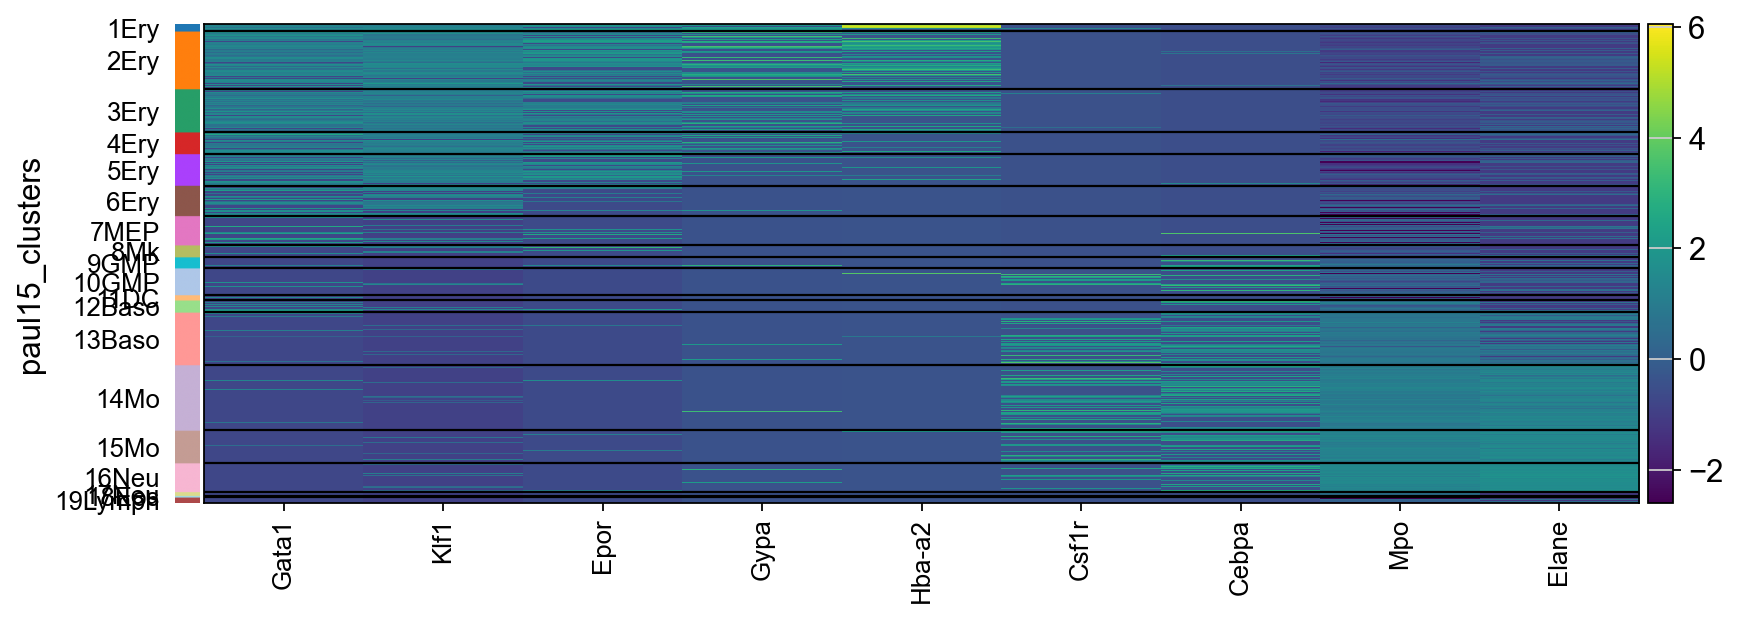

In [7]:
# Key marker genes for each lineage in the paul15 dataset (mouse gene names)
erythroid_genes = ['Gata1', 'Klf1', 'Epor', 'Gypa', 'Hba-a2']  # erythrocyte fate
myeloid_genes   = ['Csf1r', 'Cebpa', 'Mpo', 'Elane']            # myeloid fate

# Heatmap: cells sorted by pseudotime, showing how marker genes change across the trajectory
# Using cluster groupby to preserve biological context alongside the gradient
sc.pl.heatmap(
    adata,
    var_names=erythroid_genes + myeloid_genes,
    groupby='paul15_clusters',
    show_gene_labels=True,
    figsize=(12, 4),
    swap_axes=False
)

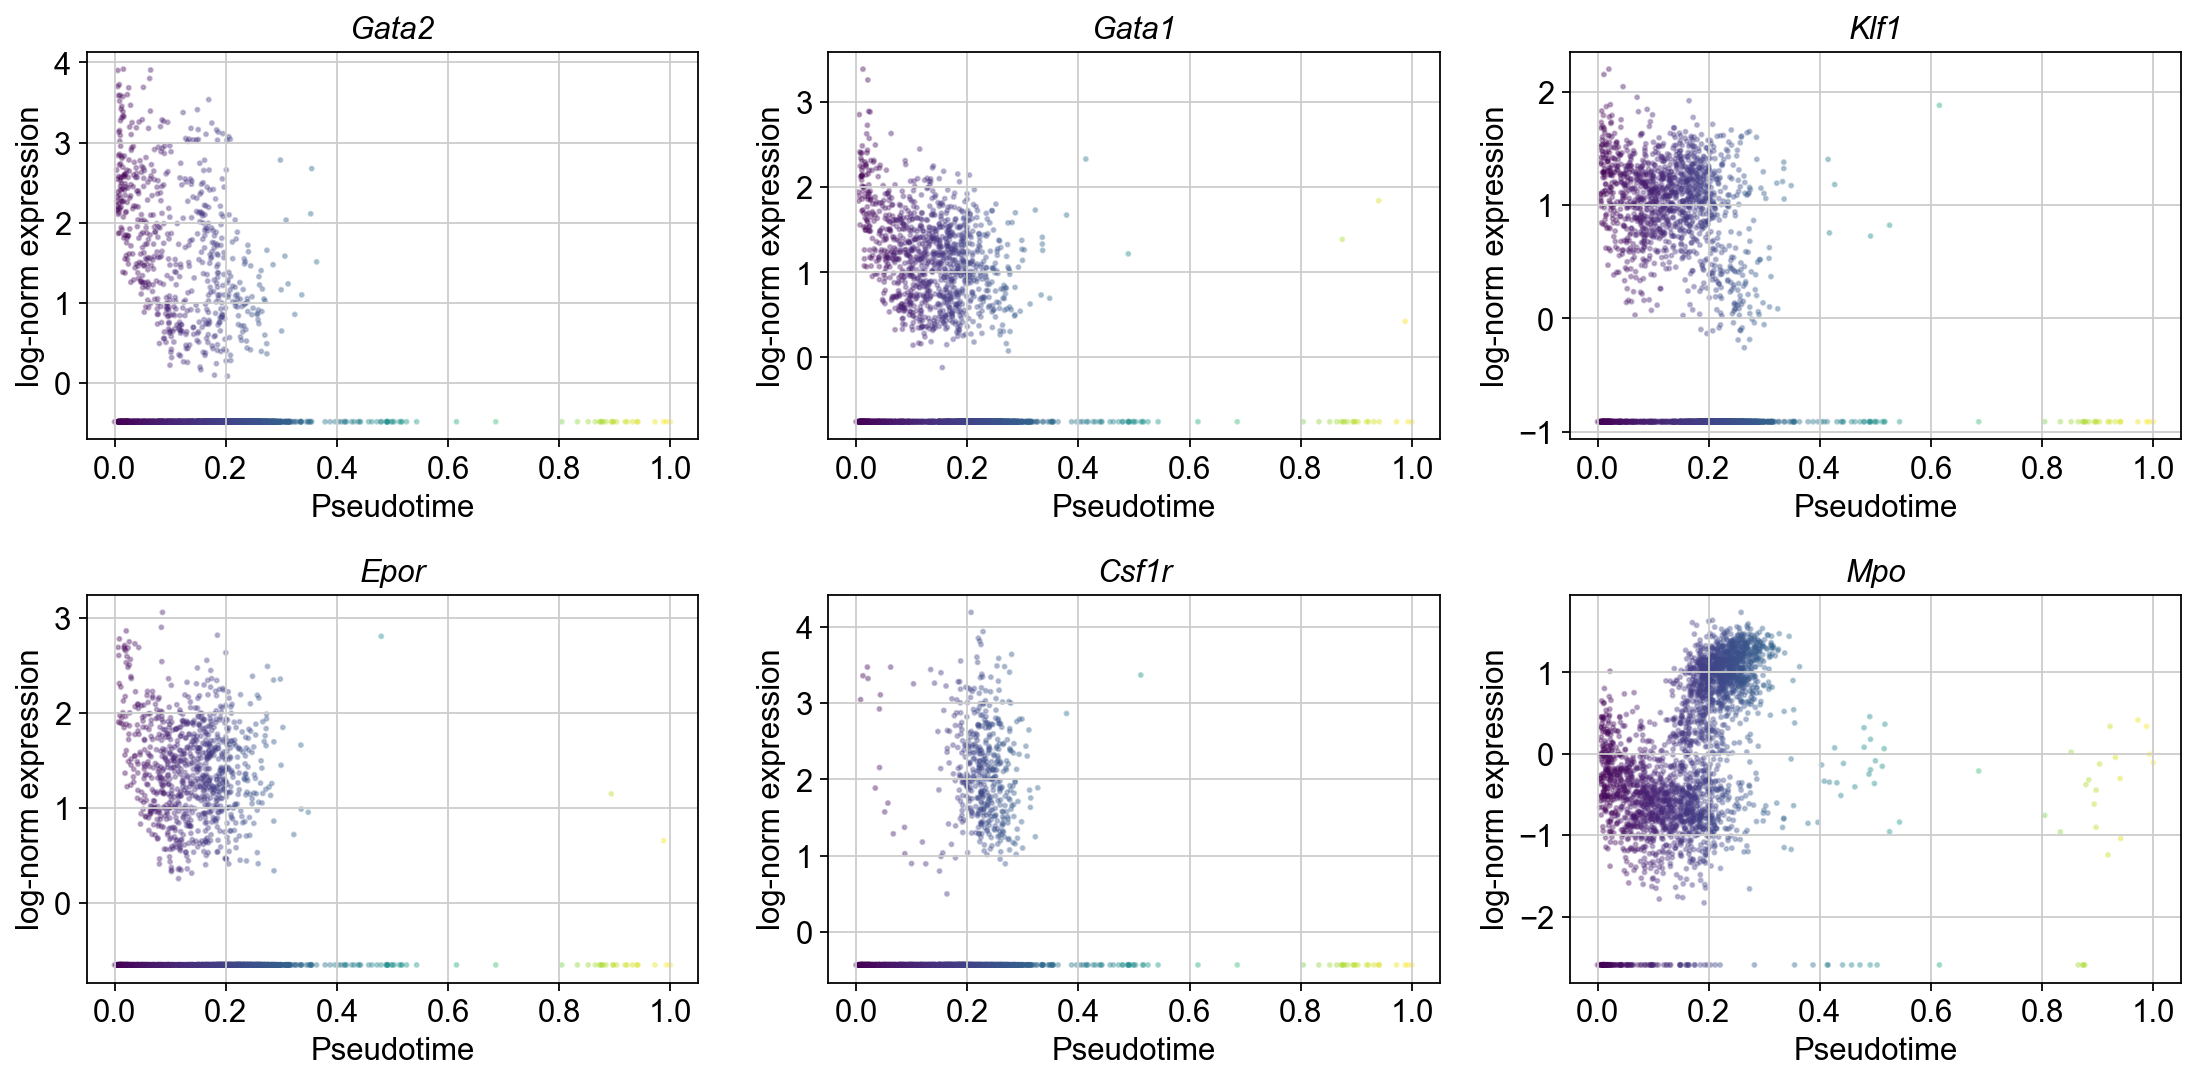

In [8]:
# Scatter plot: pseudotime vs expression for selected genes
# This shows the continuous gene expression trend along the trajectory
fig, axes = plt.subplots(2, 3, figsize=(14, 7))
genes_to_plot = ['Gata2', 'Gata1', 'Klf1', 'Epor', 'Csf1r', 'Mpo']

for ax, gene in zip(axes.flat, genes_to_plot):
    if gene in adata.var_names:
        expr = adata[:, gene].X
        if hasattr(expr, 'toarray'):
            expr = expr.toarray().flatten()
        else:
            expr = np.asarray(expr).flatten()
        pt = adata.obs['dpt_pseudotime'].values
        ax.scatter(pt, expr, s=3, alpha=0.3, c=pt, cmap='viridis')
        ax.set_title(gene, fontstyle='italic')
        ax.set_xlabel('Pseudotime')
        ax.set_ylabel('log-norm expression')
    else:
        ax.set_title(f'{gene} (not in HVGs)')
        ax.axis('off')

plt.tight_layout()
plt.show()

---
# 7. Limitations and Interpretation
---

## What pseudotime can tell you

- The relative ordering of transcriptional states along a process
- Which genes are early or late markers in a differentiation trajectory
- The overall topology of transitions (linear, branching, cyclic)

## What pseudotime cannot tell you

**Pseudotime is not real time.** A cell at pseudotime 0.8 is not 80% of the way through a process in minutes or days — it is simply transcriptionally more distant from the root than a cell at 0.2.

**Direction is not inferred from the data alone.** The algorithm orders cells by transcriptional distance from the root, but the choice of root is yours. A poor root choice produces a pseudotime gradient that runs backwards relative to biology — and the algorithm cannot detect this.

**Branching is assumed, not discovered.** DPT handles branching trajectories, but identifies them based on topology in diffusion space. In complex datasets with many lineages, this can produce artifacts. Tools like Monocle3 or PAGA-based trajectory inference offer more explicit branching models.

## When not to use pseudotime

- When cells are mature and terminally differentiated with no meaningful ordering (e.g., PBMC immune cells at steady state)
- When clusters are clearly discrete with no connecting bridge cells in the kNN graph
- When you do not have a biologically motivated choice of root